# Libraries and functions

In [15]:
import numpy as np
import matplotlib.pyplot as plt


import numpy as np
import matplotlib.pyplot as plt


def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))


def rhm_level_floors(v: int, m: int, s: int, L: int):
    """
    Loss plateaus consistent with the paper.

    Returns:
      levels
      Nbar_exact      : exact finite-(v,m) average compatible-set sizes
      loss_upper      : paper's upper bounds \bar L_l = log Nbar_l
      err_heuristic   : simple heuristic, NOT from the paper
      acc_heuristic   : simple heuristic, NOT from the paper
    """
    denom = v**s - 1
    alpha = m * (v - 1) / denom

    if not (0 < alpha < 1):
        raise ValueError(
            f"Need alpha = m (v-1)/(v^s-1) in (0,1), got alpha={alpha:.6g}."
        )

    levels = np.arange(L + 1)

    # exact recurrence from the paper
    Nbar = np.zeros(L + 1, dtype=float)
    Nbar[0] = float(v)
    if L >= 1:
        Nbar[1] = 1.0 + (v - 1.0) * (m * v - 1.0) / (v**s - 1.0)
    for ell in range(2, L + 1):
        Nbar[ell] = 1.0 + (v - 1.0) * (m * Nbar[ell - 1] - 1.0) / (v**s - 1.0)

    # paper's dashed lines: upper bounds on loss
    loss_upper = np.log(Nbar)

    # heuristic only, not from the paper
    err_heuristic = 1.0 - 1.0 / Nbar
    acc_heuristic = 1.0 / Nbar

    return levels, Nbar, loss_upper, err_heuristic, acc_heuristic, alpha


def rhm_solved_fractions(norm, m: int, s: int, L: int, beta: float = 12.0, combine=True):
    """
    Toy cumulative solved fractions r_l(norm), with first shoulder normalized to norm=1.

    This part is phenomenological and independent of the paper's plateau formulas.
    """
    norm = np.asarray(norm, dtype=float)
    r = np.zeros((L + 1, norm.size), dtype=float)
    r[0] = 1.0

    for ell in range(1, L + 1):
        if combine:
            K = (s**ell - 1) / (s - 1)
            extra = np.exp(-K)
        else:
            extra = 1.0

        # keep the same normalization: first shoulder near norm=1
        margin = norm * (m ** (1 - ell)) * (r[ell - 1] ** s) * extra - 1.0
        r[ell] = sigmoid(beta * margin)

    return r


def rhm_ideal_curves(norm, v: int, m: int, s: int, L: int, beta: float = 12.0, combine=True):
    levels, Nbar, Lfloors, Efloors, Afloors, alpha = rhm_level_floors(v, m, s, L)
    r = rhm_solved_fractions(norm, m=m, s=s, L=L, beta=beta, combine=combine)

    dL = Lfloors[:-1] - Lfloors[1:]
    dE = Efloors[:-1] - Efloors[1:]
    dA = Afloors[1:] - Afloors[:-1]

    loss = Lfloors[0] - np.tensordot(dL, r[1:], axes=(0, 0))
    err = Efloors[0] - np.tensordot(dE, r[1:], axes=(0, 0))
    acc = Afloors[0] + np.tensordot(dA, r[1:], axes=(0, 0))

    return {
        "norm": np.asarray(norm, dtype=float),
        "r": r,
        "levels": levels,
        "Nbar": Nbar,
        "loss_floors": Lfloors,
        "err_floors": Efloors,   # heuristic
        "acc_floors": Afloors,   # heuristic
        "loss": loss,
        "err": err,
        "acc": acc,
        "alpha": alpha,
    }


def plot_rhm_ideal_curves(
    v: int,
    m: int,
    s: int,
    L: int,
    beta: float = 12.0,
    norm_min: float = 1e-2,
    norm_max: float = 1e4,
    num_points: int = 1200,
    show_level_lines: bool = True,
    figsize=(12, 4.6),
    combine = True,
):
    norm = np.logspace(np.log10(norm_min), np.log10(norm_max), num_points)
    out = rhm_ideal_curves(norm, v=v, m=m, s=s, L=L, beta=beta, combine=combine)

    fig, axes = plt.subplots(1, 2, figsize=figsize, constrained_layout=True)

    ax = axes[0]
    ax.plot(out["norm"], 1-out["acc"], lw=2)
    if show_level_lines:
        for a in out["acc_floors"]:
            ax.axhline(1-a, ls="--", lw=0.8, alpha=0.5)
    #ax.axvline(1.0, ls=":", lw=1.2, alpha=0.8)
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel(r"normalized norm $\mathcal{N}/\mathcal{N}_1^c$")
    ax.set_ylabel("error")
    ax.set_title("Ideal RHM error vs norm")

    ax = axes[1]
    ax.plot(out["norm"], out["loss"], lw=2)
    if show_level_lines:
        for lf in out["loss_floors"]:
            ax.axhline(lf, ls="--", lw=0.8, alpha=0.5)
    #ax.axvline(1.0, ls=":", lw=1.2, alpha=0.8)
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel(r"normalized norm $\mathcal{N}/\mathcal{N}_1^c$")
    ax.set_ylabel("cross-entropy loss")
    ax.set_title("Ideal RHM loss vs norm")

    fig.suptitle(
        f"Equal-probability RHM toy theory (v={v}, m={m}, s={s}, L={L}, beta={beta})",
        y=1.03
    )
    return fig, axes, out


# Test

## L=3, s=2, v=32, m=8

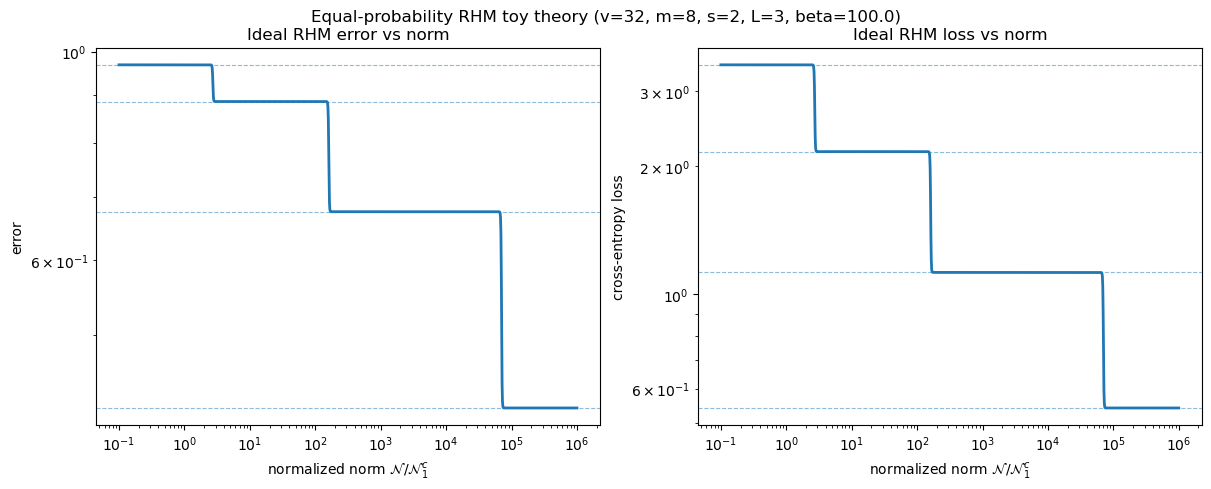

In [16]:
fig, axes, out = plot_rhm_ideal_curves(v=32, m=8, s=2, L=3, beta=100.0, norm_min=0.1, norm_max=1e6, combine = True)
plt.show()

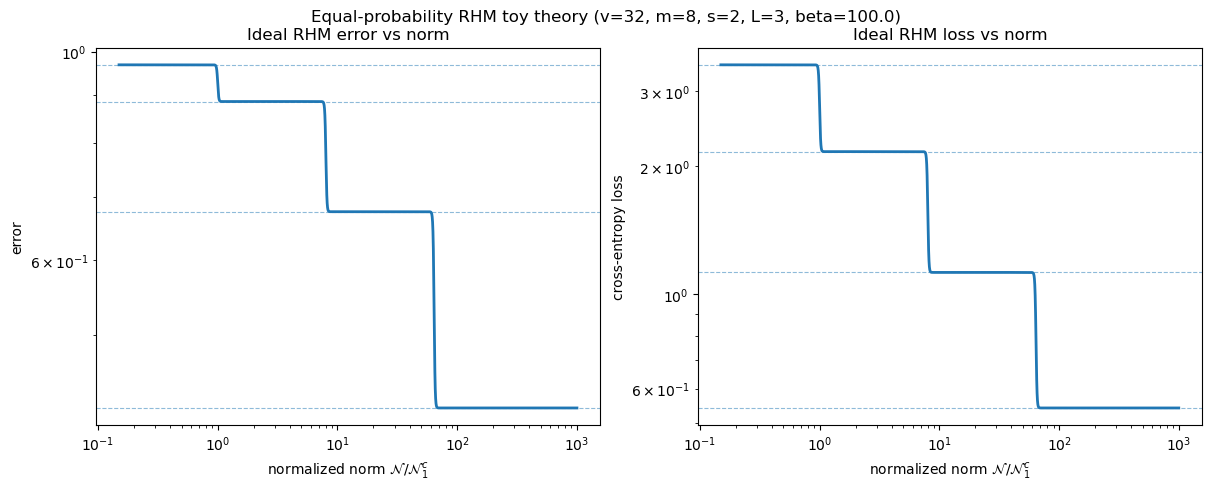

In [23]:
fig, axes, out = plot_rhm_ideal_curves(v=32, m=8, s=2, L=3, beta=100.0, norm_min=1.5e-1, norm_max=1e3, combine = False)
plt.show()

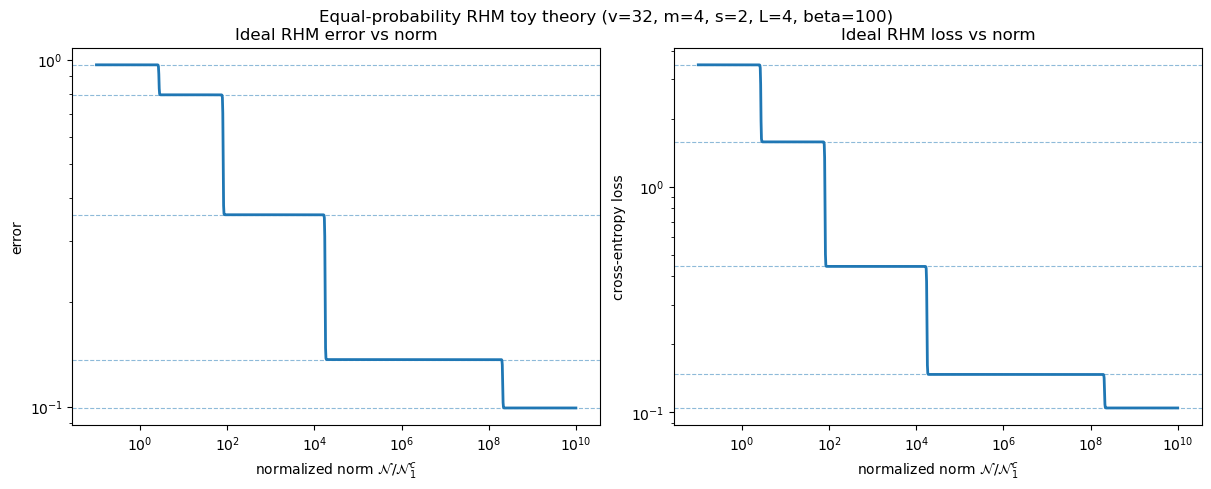

In [20]:
fig, axes, out = plot_rhm_ideal_curves(v=32, m=4, s=2, L=4, beta=100, norm_min=1e-1, norm_max=1e10)
plt.show()